# PySpectrum Example 
## Global background estimation
Spectra analysis sometimes require estimated continuous background (especially where it is not known).\
The background can be estimated using various methods some of them are realized in pySpectgrum

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create calibrated Spectrum 
from pyspectrum.core import Spectrum, Domain
from pyspectrum.io import TimeChannelParser
from pyspectrum.calibration.detector_calibration import DetectorCalibration
from pyspectrum.calibration import AxisCalibration, ResolutionCalibration

# identification of peaks
from pyspectrum.identification import Convolution
from pyspectrum.identification.snr import SNRFinder
from pyspectrum.identification.kernels.mexican_hat import gaussian_2_dev

# domain charactrization

# background subtraction
from pyspectrum.background.snip import SNIPBackground
from pyspectrum.background.minimum_in_envolope import MinimaEnvelopeBackground
from pyspectrum.background.polynomial import IterativePolyFit, IterativePolyFitWithMinimum
from pyspectrum.background.als import ALSBackground

from pyspectrum.domain_analysis.background import domain_erf_background, domain_linear_background

# load the spectrum

In [2]:
path = '../Library/152Eu_calsource_10cm_85ks.txt'
spectrum = pd.read_csv(path, names=['counts'])
spectrum['channel'] = spectrum.index 

axis_calibration = AxisCalibration(np.poly1d([0.29239695, 7.10512435]), "energy")

spectrum = Spectrum.from_dataframe(spectrum,
                                   axis_calib=axis_calibration)

domains = [(383, 403), (1140,1165), (1485, 1505), (2627, 2650), (3260,3285), (4770, 4810)]
energies = [121.78, 344.28, 443.96, 778.9, 964.08, 1408]

calib = DetectorCalibration(spectrum=spectrum, peak_domains=domains, known_axis_values=energies)
energy_calibration, resolution_calibration = calib.generate()
spectrum.set_axis_calibration(energy_calibration)
spectrum.set_resolution_calibration(resolution_calibration)

# remove the begining zeros from spectrum
# this improves the global estimation
i_start = np.where(spectrum.counts>0)[0][0]
i_stop = len(spectrum.axis)
modified_axis_calibration =  lambda e: energy_calibration.apply(e) -energy_calibration.apply(0)+energy_calibration.apply(i_start)
spectrum = Spectrum(
    counts=spectrum.counts[i_start:i_stop],
    channels=spectrum.channels[i_start:i_stop]-i_start,
    axis_calib=AxisCalibration(func=modified_axis_calibration, name="energy"),
    resolution_calib=spectrum.resolution_calib
)

In [3]:
conv = Convolution(resolution=resolution_calibration.apply, kernel=gaussian_2_dev, window_fwhm=4)
finder = SNRFinder(convolution=conv, n_sigma_signal_threshold=5, n_sigma_bg_threshold=2.5, persistence_factor=0.5)
domains = finder.find(spectrum)
domain = domains[26]

Text(0, 0.5, 'counts')

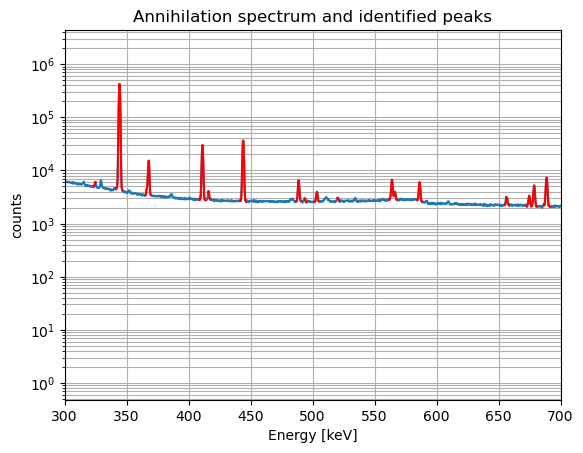

In [4]:
spectrum.plot(yscale='log')
for domain in domains:
    try:
        domain.plot(color='red')
    except:
        pass
    
plt.xlim([300, 700])
plt.grid(True, which='both')
plt.title('Annihilation spectrum and identified peaks')
plt.xlabel('Energy [keV]')
plt.ylabel('counts')

# Global Background Estimation Methods
Here we gonna go over the variuos metrhods for the background estimation

## SNIP background subtraction

In [5]:
snip_bg = SNIPBackground(30)
bg_estimation = snip_bg.estimate(axis=spectrum.axis, counts=spectrum.counts, resolution=spectrum.resolution_calib.apply, smoothing=True)

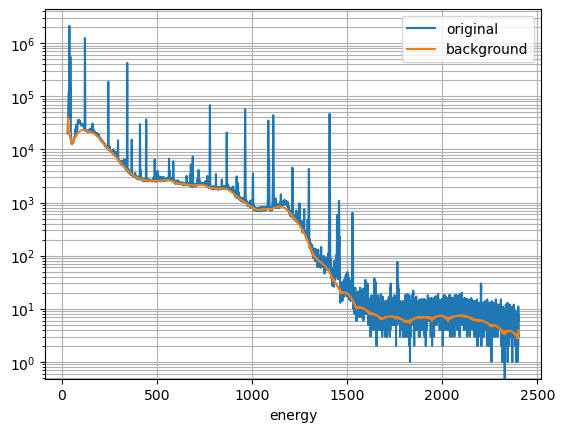

In [6]:
spectrum.plot(yscale='log', label='original')
plt.plot(spectrum.axis, bg_estimation, label='background')

plt.grid(True, which='both')
plt.legend()

# Minimum in Envelope method

In [7]:
me_bg = MinimaEnvelopeBackground(window_scale=5.0, snr_threshold=4.0)
me_bg_estimation = me_bg.estimate(axis=spectrum.axis,
                               counts=spectrum.counts,
                               resolution_calib=spectrum.resolution_calib,
                               conv=conv,
                              iterations=5)

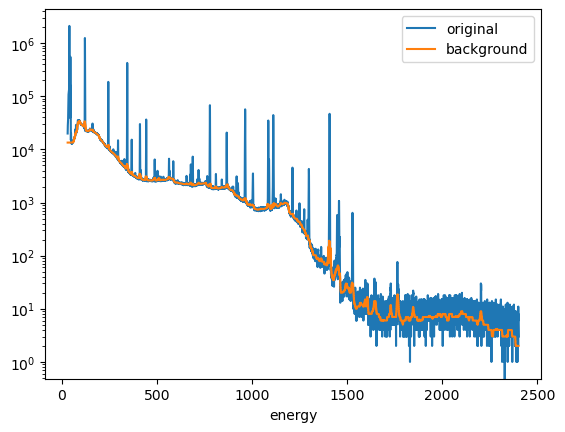

In [8]:
spectrum.plot(yscale='log', label='original')
plt.step(spectrum.axis, me_bg_estimation, label='background')

plt.legend()

# ALS

In [27]:
est = ALSBackground(lam=1e5, p=0.001, max_iter=50)
als_bg = est.estimate(spectrum.axis, spectrum.counts)

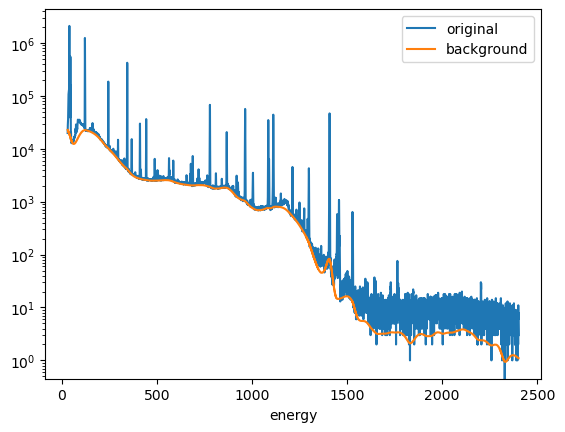

In [28]:
spectrum.plot(yscale='log', label='original')
plt.step(spectrum.axis, als_bg, label='background')

plt.legend()

## Polynomial method
This method isn't a very good one for gamma spectroscopy but is appropriate for other applications

In [33]:
est = IterativePolyFit(degree=6, max_iter=25, tolerance=0.001)
poly_bg = est.estimate(spectrum.axis, spectrum.counts)

/tmp/ipykernel_33749/2380623778.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


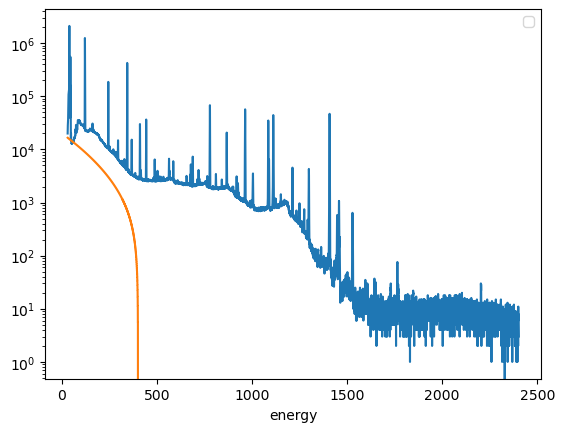

In [34]:
spectrum.plot(yscale='log')
plt.step(spectrum.axis, poly_bg)

plt.legend()

## Polynomial method with minimum 

In [31]:
est = IterativePolyFitWithMinimum(degree=5,max_iter=100,tolerance=1e-3,window_scale=5.0,snr_threshold=4.0,)
poly_with_min_bg = est.estimate(spectrum.axis, spectrum.counts, spectrum.resolution_calib, conv)

/tmp/ipykernel_33749/2763183574.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


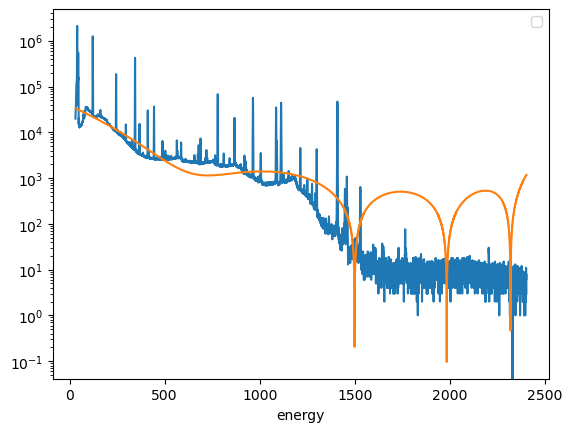

In [32]:
spectrum.plot(yscale='log')
plt.step(spectrum.axis, np.abs(poly_with_min_bg))

plt.legend()